# Track 3 — Generation Quality Analysis

Analyses LLM generation quality from `pipeline_report.json`.

Figures produced:
- `fig_05_generation_metrics.png` — bar chart of faithfulness / citation / section / hallucination rates
- `fig_06_token_usage.png` — box plot of prompt / completion / total tokens
- Per-case styled table with color coding (green=pass, red=fail per metric)

**Prerequisites:** `make eval-pipeline` (requires services running)

In [ ]:
import json
import sys
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path("../..").resolve()
PIPELINE_REPORT = ROOT / "evaluation" / "results" / "pipeline_report.json"
FIG_DIR = ROOT / "evaluation" / "notebooks" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

if not PIPELINE_REPORT.exists():
    print(f"pipeline_report.json not found at {PIPELINE_REPORT}")
    print("Run 'make eval-pipeline' (requires: make up) first.")
    raise SystemExit(0)

with open(PIPELINE_REPORT, encoding="utf-8") as f:
    report = json.load(f)

agg = report.get("aggregate_metrics", {})
print(f"Report timestamp:    {report['timestamp']}")
print(f"Cases evaluated:     {agg.get('total_cases')}")
# Support both old ("faithfulness_rate") and new ("decision_consistency_rate") key
dcr = agg.get("decision_consistency_rate", agg.get("faithfulness_rate", 0))
print(f"Decision consistency:{dcr:.4f}")
print(f"Citation coverage:   {agg.get('citation_coverage_rate', 0):.4f}")
print(f"Section completeness:{agg.get('section_completeness_rate', 0):.4f}")
print(f"Hallucination rate:  {agg.get('hallucination_rate', 0):.4f}")

In [2]:
# Build case-level DataFrame
df = pd.DataFrame(report.get("case_results", []))
df["nota"] = df["case_id"].str[:3]
# Expand token_usage sub-dicts
if "token_usage" in df.columns:
    tok = df["token_usage"].apply(pd.Series)
    df = pd.concat([df.drop("token_usage", axis=1), tok], axis=1)
print(f"DataFrame shape: {df.shape}")
df.head(3)

DataFrame shape: (37, 17)


,case_id,description,category,faithful,citation_complete,has_hallucination,sections_complete,strings_ok,overall_pass,details,llm_model,retrieved_chunks_metadata,latency_s,nota,prompt_tokens,completion_tokens,total_tokens
0,N97-001,Standard eligible male: CHA2DS2-VASc=3 (H+D+sc...,RIMBORSABILE_standard,True,True,False,True,True,True,"{'decision_consistent': True, 'decision_contra...",ollama/llama3.1:8b,"[{'chunk_id': 'nota-97_0000', 'pdf_file': 'not...",7.89,N97,4096,247,4343
1,N97-002,Eligible female: CHA2DS2-VASc=4 (H+D+scompenso...,RIMBORSABILE_female,True,True,False,True,True,True,"{'decision_consistent': True, 'decision_contra...",ollama/llama3.1:8b,"[{'chunk_id': 'nota-97_0000', 'pdf_file': 'not...",9.64,N97,4096,407,4503
2,N97-003,NON_RIMBORSABILE — Scope failure: ECG not conf...,NON_RIMBORSABILE_scope,True,True,False,True,True,True,"{'decision_consistent': True, 'decision_contra...",ollama/llama3.1:8b,"[{'chunk_id': 'nota-97_0000', 'pdf_file': 'not...",9.62,N97,4096,407,4503


In [ ]:
# Cell 3 — Track 3 aggregate metrics bar chart
dcr = agg.get("decision_consistency_rate", agg.get("faithfulness_rate", 0))
THRESHOLDS = {
    "Decision\nconsistency":   (dcr,                                    1.00),
    "Citation\ncoverage rate": (agg.get("citation_coverage_rate", 0),    0.90),
    "Section\ncompleteness":   (agg.get("section_completeness_rate", 0), 1.00),
    "No-hallucination\nrate":  (1 - agg.get("hallucination_rate", 0),    0.90),
}

labels  = list(THRESHOLDS.keys())
values  = [v[0] for v in THRESHOLDS.values()]
targets = [v[1] for v in THRESHOLDS.values()]
colors  = ["#2ecc71" if v >= t else "#e74c3c" for v, t in zip(values, targets)]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, values, color=colors, edgecolor="white", linewidth=0.7)
for bar, tgt in zip(bars, targets):
    ax.axhline(y=tgt, xmin=bar.get_x() / ax.get_xlim()[1],
               color="#2c3e50", linewidth=1.2, linestyle="--", alpha=0.6)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{val:.1%}", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_ylim(0, 1.15)
ax.set_ylabel("Rate", fontsize=11)
ax.set_title("Track 3 — Generation Quality Metrics", fontsize=13)
green_patch = mpatches.Patch(color="#2ecc71", label="Meets threshold")
red_patch   = mpatches.Patch(color="#e74c3c", label="Below threshold")
ax.legend(handles=[green_patch, red_patch], loc="lower right")
plt.tight_layout()
fig.savefig(FIG_DIR / "fig_05_generation_metrics.png", dpi=150)
plt.show()
print("Saved fig_05_generation_metrics.png")

/tmp/ipykernel_88463/1156950298.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


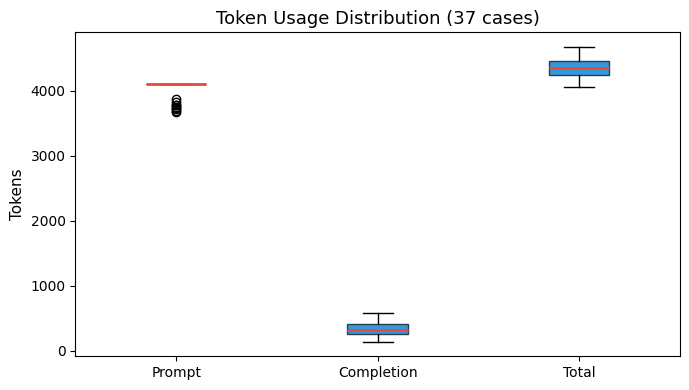

Saved fig_06_token_usage.png


In [4]:
# Cell 4 — Token usage box plot
token_cols = [c for c in ["prompt_tokens", "completion_tokens", "total_tokens"] if c in df.columns]
if token_cols:
    fig, ax = plt.subplots(figsize=(7, 4))
    bp = ax.boxplot(
        [df[c].dropna() for c in token_cols],
        labels=["Prompt", "Completion", "Total"],
        patch_artist=True,
        boxprops=dict(facecolor="#3498db", color="#2c3e50"),
        medianprops=dict(color="#e74c3c", linewidth=2),
    )
    ax.set_ylabel("Tokens", fontsize=11)
    ax.set_title("Token Usage Distribution (37 cases)", fontsize=13)
    plt.tight_layout()
    fig.savefig(FIG_DIR / "fig_06_token_usage.png", dpi=150)
    plt.show()
    print("Saved fig_06_token_usage.png")
else:
    print("No token columns found in report — skipping box plot")

In [ ]:
# Cell 5 — Per-category breakdown
breakdown = report.get("category_breakdown", {})
if breakdown:
    bdf = pd.DataFrame([
        {"category": cat, **vals}
        for cat, vals in breakdown.items()
    ])
    # Support both old ("faithful") and new ("decision_consistent") key
    dc_col = "decision_consistent" if "decision_consistent" in bdf.columns else "faithful"
    bdf["decision_consistency_rate"] = bdf[dc_col] / bdf["total"]
    bdf["citation_rate"]             = bdf["citation_complete"] / bdf["total"]
    bdf["pass_rate"]                 = bdf["pass"] / bdf["total"]
    display(bdf[["category", "total", "pass", "pass_rate",
                 dc_col, "decision_consistency_rate",
                 "citation_complete", "citation_rate"]]
            .sort_values("total", ascending=False)
            .style.format({
                "pass_rate":                  "{:.1%}",
                "decision_consistency_rate":  "{:.1%}",
                "citation_rate":              "{:.1%}",
            })
           )

In [ ]:
# Cell 6 — Per-case styled table (green=pass, red=fail per metric)
# Support both old ("faithful") and new ("decision_consistent") key
dc_col = "decision_consistent" if "decision_consistent" in df.columns else "faithful"
bool_cols = [dc_col, "citation_complete", "sections_complete", "strings_ok",
             "has_hallucination", "overall_pass"]
present_bool_cols = [c for c in bool_cols if c in df.columns]

def color_bool(val):
    if val is True:
        return "background-color: #d4edda"
    elif val is False:
        return "background-color: #f8d7da"
    return ""

display_cols = ["case_id", "category"] + present_bool_cols
display_cols = [c for c in display_cols if c in df.columns]

# pandas >=2.1 renamed Styler.applymap → Styler.map
styler = df[display_cols].style
if hasattr(styler, "map"):
    styled = styler.map(color_bool, subset=present_bool_cols)
else:
    styled = styler.applymap(color_bool, subset=present_bool_cols)
display(styled)

In [7]:
# Cell 7 — String criteria failures (prompt tuning input)
if "details" in df.columns:
    failed_string_cases = [
        r for r in report.get("case_results", [])
        if not r.get("strings_ok", True)
    ]
    if failed_string_cases:
        print(f"{len(failed_string_cases)} cases with string criteria failures:\n")
        for r in failed_string_cases:
            checks = r.get("details", {}).get("string_checks", {})
            failed = [k for k, v in checks.items() if not v]
            print(f"  {r['case_id']}: {r['description'][:60]}")
            for f in failed:
                print(f"    FAILED: {f}")
    else:
        print("All string criteria passed.")

1 cases with string criteria failures:

  N13-007: RIMBORSABILE — bypass N13_EXCEPT_002: documented statin into
    FAILED: contains:'ezetimibe'
